### Syed Obaidullah Hassan Chishti - 25280049

# Imports

In [328]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader
from datetime import datetime
import os
import json
from sklearn.metrics import classification_report
import torchvision.transforms as transforms
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Check Cuda Device

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Code auto completed by Co-Pilot

Using device: cuda


# Load Datasets

In [270]:
data_dir = "processed_data/"
train_data_file = "quickdraw_train.npz"
test_data_file = "quickdraw_test.npz"

In [ ]:
train_data = np.load(data_dir + train_data_file)
test_data = np.load(data_dir + test_data_file)

# Code auto completed by Co-Pilot

In [272]:
train_data['class_names']

array(['apple', 'baseballbat', 'basketball', 'clock', 'compass', 'cookie',
       'donut', 'ladder', 'mountain', 'pizza', 'rabbit', 'soccerball',
       'spider', 't-shirt', 'wheel'], dtype='<U11')

In [ ]:
X_train = train_data['x_train'].astype(np.float32)
y_train = train_data['y_train']

print("Train Data Shape: ", X_train.shape)
print("Train Labels Shape: ", y_train.shape)

# Code auto completed by Co-Pilot


Train Data Shape:  (60000, 784)
Train Labels Shape:  (60000,)


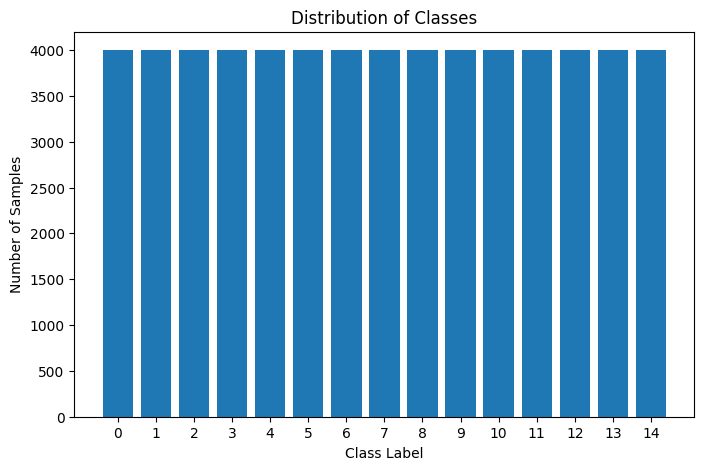

In [ ]:
# Class Distribution
classes, counts = np.unique(y_train, return_counts=True)

plt.figure(figsize=(8,5))
plt.bar(classes, counts)

plt.xlabel("Class Label")
plt.ylabel("Number of Samples")
plt.title("Distribution of Classes")
plt.xticks(classes)

plt.show()

# Code auto completed by Co-Pilot

# Transformations

## Split Into Train, Val, Test

In [ ]:
X_train_split, X_temp, y_train_split, y_temp = train_test_split(
    X_train,
    y_train,
    test_size=0.20,
    stratify=y_train, 
    random_state=42
)

X_val_split, X_test_split, y_val_split, y_test_split = train_test_split(
    X_temp,
    y_temp,
    test_size=0.25,
    stratify=y_temp,
    random_state=42
)

# Code auto completed by Co-Pilot. Added stratify parameter and changes test_size for both

## Normalize Data

In [276]:
X_train_normalized = X_train_split / 255.0  
X_val_normalized   = X_val_split   / 255.0
X_test_normalized  = X_test_split  / 255.0

## Convert to PyTorch Tensors

In [ ]:
X_train_tensor = torch.from_numpy(X_train_split)
y_train_tensor = torch.from_numpy(y_train_split)

X_val_tensor = torch.from_numpy(X_val_split)
y_val_tensor = torch.from_numpy(y_val_split)

X_test_tensor = torch.from_numpy(X_test_split)
y_test_tensor = torch.from_numpy(y_test_split)

# Code auto completed by Co-Pilot

## Create PyTorch Datasets

In [ ]:
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset   = TensorDataset(X_val_tensor, y_val_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

# Code auto completed by Co-Pilot

## Create Data Loaders

In [ ]:
batch_size = 128

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader   = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# Code auto completed by Co-Pilot


# Pancake Model

## Initialize Model

In [ ]:
class PancakeModel(nn.Module):
    def __init__(self, input_size=784, hidden_size=2048, num_classes=15):
        super(PancakeModel, self).__init__()

        self.network = nn.Sequential(
            nn.Linear(input_size, hidden_size),
            nn.ReLU(),

            nn.Linear(hidden_size, hidden_size),
            nn.ReLU(),

            nn.Linear(hidden_size, num_classes)
        )

    def forward(self, x):
        return self.network(x)

# Code auto completed by Co-Pilot

In [ ]:
pancake_model = PancakeModel().to(device)

# Code auto completed by Co-Pilot

## Initilize Loss and Optimizer

In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(pancake_model.parameters(), lr=0.001)

# Code auto completed by Co-Pilot

## Run Training and Validation

In [ ]:
epochs = 10

train_losses_pancake = []
val_losses_pancake = []

train_accuracies_pancake = []
val_accuracies_pancake = []

for epoch in range(epochs):

    # ----- TRAIN -----
    pancake_model.train()
    train_loss = 0
    train_correct = 0
    train_total = 0

    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)

        optimizer.zero_grad()

        outputs = pancake_model(X_batch)
        loss = criterion(outputs, y_batch)

        loss.backward()
        optimizer.step()

        train_loss += loss.item()

        preds = torch.argmax(outputs, dim=1)
        train_correct += (preds == y_batch).sum().item()
        train_total += y_batch.size(0)

    train_loss /= len(train_loader)   # average loss
    train_acc = train_correct / train_total

    # ----- VALIDATION -----
    pancake_model.eval()
    val_loss = 0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)

            outputs = pancake_model(X_batch)
            loss = criterion(outputs, y_batch)

            val_loss += loss.item()

            preds = torch.argmax(outputs, dim=1)
            val_correct += (preds == y_batch).sum().item()
            val_total += y_batch.size(0)

    val_loss /= len(val_loader)
    val_acc = val_correct / val_total

    # ✅ STORE METRICS
    train_losses_pancake.append(train_loss)
    val_losses_pancake.append(val_loss)

    train_accuracies_pancake.append(train_acc)
    val_accuracies_pancake.append(val_acc)

    print(f"Epoch {epoch+1}/{epochs} | "
          f"Train Loss: {train_loss:.4f} | "
          f"Val Loss: {val_loss:.4f} | "
          f"Train Acc: {train_acc:.4f} | "
          f"Val Acc: {val_acc:.4f}")
    
# Code auto completed by Co-Pilot

Epoch 1/10 | Train Loss: 3.2422 | Val Loss: 1.1599 | Train Acc: 0.5410 | Val Acc: 0.6242
Epoch 2/10 | Train Loss: 1.0081 | Val Loss: 1.0215 | Train Acc: 0.6657 | Val Acc: 0.6667
Epoch 3/10 | Train Loss: 0.9010 | Val Loss: 1.0050 | Train Acc: 0.6982 | Val Acc: 0.6747
Epoch 4/10 | Train Loss: 0.8349 | Val Loss: 1.0038 | Train Acc: 0.7172 | Val Acc: 0.6842
Epoch 5/10 | Train Loss: 0.7900 | Val Loss: 0.9689 | Train Acc: 0.7307 | Val Acc: 0.6952
Epoch 6/10 | Train Loss: 0.7538 | Val Loss: 0.9698 | Train Acc: 0.7437 | Val Acc: 0.6928
Epoch 7/10 | Train Loss: 0.7302 | Val Loss: 1.0417 | Train Acc: 0.7485 | Val Acc: 0.6907
Epoch 8/10 | Train Loss: 0.6993 | Val Loss: 1.0394 | Train Acc: 0.7589 | Val Acc: 0.6993
Epoch 9/10 | Train Loss: 0.6866 | Val Loss: 1.0727 | Train Acc: 0.7627 | Val Acc: 0.7057
Epoch 10/10 | Train Loss: 0.6633 | Val Loss: 1.1181 | Train Acc: 0.7717 | Val Acc: 0.7029


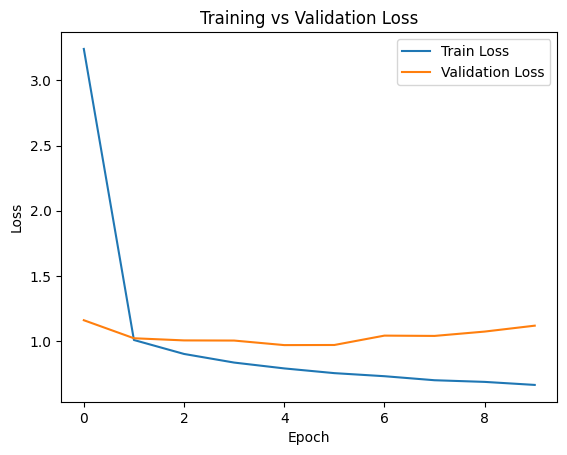

In [ ]:
plt.figure()
plt.plot(train_losses_pancake, label="Train Loss")
plt.plot(val_losses_pancake, label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.show()

# Code auto completed by Co-Pilot

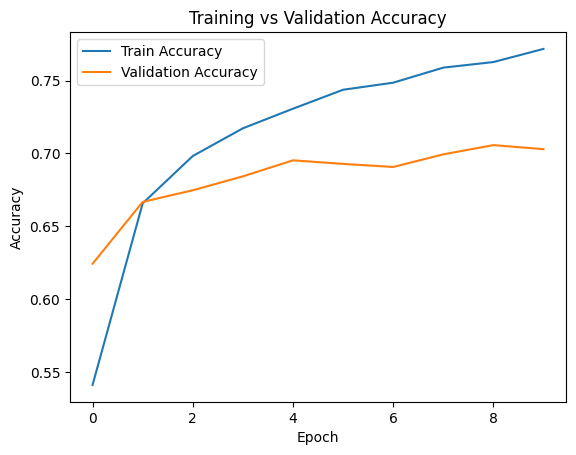

In [ ]:
plt.figure()
plt.plot(train_accuracies_pancake, label="Train Accuracy")
plt.plot(val_accuracies_pancake, label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.show()

# Code auto completed by Co-Pilot

## Inferene on Test Data

In [ ]:
pancake_model.eval()
test_correct_pancake = 0
test_total_pancake = 0

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)

        outputs = pancake_model(X_batch)
        preds = torch.argmax(outputs, dim=1)

        test_correct_pancake += (preds == y_batch).sum().item()
        test_total_pancake += y_batch.size(0)

test_accuracy_pancake = test_correct_pancake / test_total_pancake
print("Test Accuracy:", test_accuracy_pancake)

# Code auto completed by Co-Pilot

Test Accuracy: 0.7033333333333334


# Tower Model

## Initialize Model

In [ ]:
class TowerModel(nn.Module):
    def __init__(self, input_size=784, hidden_size=128, num_classes=15):
        super(TowerModel, self).__init__()

        self.network = nn.Sequential(

            nn.Linear(input_size, hidden_size),
            nn.BatchNorm1d(hidden_size),
            nn.ReLU(),

            nn.Linear(hidden_size, hidden_size),
            nn.BatchNorm1d(hidden_size),
            nn.ReLU(),

            nn.Linear(hidden_size, hidden_size),
            nn.BatchNorm1d(hidden_size),
            nn.ReLU(),

            nn.Linear(hidden_size, hidden_size),
            nn.BatchNorm1d(hidden_size),
            nn.ReLU(),

            nn.Linear(hidden_size, hidden_size),
            nn.BatchNorm1d(hidden_size),
            nn.ReLU(),

            nn.Linear(hidden_size, hidden_size),
            nn.BatchNorm1d(hidden_size),
            nn.ReLU(),

            nn.Linear(hidden_size, num_classes)
        )

    def forward(self, x):
        return self.network(x)

# Code auto completed by Co-Pilot

In [ ]:
tower_model = TowerModel().to(device)

# Code auto completed by Co-Pilot

## Initilize Loss and Optimizer

In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(tower_model.parameters(), lr=0.001)

# Code auto completed by Co-Pilot

## Run Training and Validation

In [ ]:
epochs = 10

train_losses_tower = []
val_losses_tower = []

train_accuracies_tower = []
val_accuracies_tower = []

for epoch in range(epochs):

    # ----- TRAIN -----
    tower_model.train()
    train_loss = 0
    train_correct = 0
    train_total = 0

    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)

        optimizer.zero_grad()

        outputs = tower_model(X_batch)
        loss = criterion(outputs, y_batch)

        loss.backward()
        optimizer.step()

        train_loss += loss.item()

        preds = torch.argmax(outputs, dim=1)
        train_correct += (preds == y_batch).sum().item()
        train_total += y_batch.size(0)

    train_loss /= len(train_loader)   # average loss
    train_acc = train_correct / train_total

    # ----- VALIDATION -----
    tower_model.eval()
    val_loss = 0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)

            outputs = tower_model(X_batch)
            loss = criterion(outputs, y_batch)

            val_loss += loss.item()

            preds = torch.argmax(outputs, dim=1)
            val_correct += (preds == y_batch).sum().item()
            val_total += y_batch.size(0)

    val_loss /= len(val_loader)
    val_acc = val_correct / val_total

    # ✅ STORE METRICS
    train_losses_tower.append(train_loss)
    val_losses_tower.append(val_loss)

    train_accuracies_tower.append(train_acc)
    val_accuracies_tower.append(val_acc)

    print(f"Epoch {epoch+1}/{epochs} | "
          f"Train Loss: {train_loss:.4f} | "
          f"Val Loss: {val_loss:.4f} | "
          f"Train Acc: {train_acc:.4f} | "
          f"Val Acc: {val_acc:.4f}")
    
# Code auto completed by Co-Pilot

Epoch 1/10 | Train Loss: 1.1239 | Val Loss: 0.8878 | Train Acc: 0.6342 | Val Acc: 0.7033
Epoch 2/10 | Train Loss: 0.8201 | Val Loss: 0.8238 | Train Acc: 0.7254 | Val Acc: 0.7214
Epoch 3/10 | Train Loss: 0.7225 | Val Loss: 0.7864 | Train Acc: 0.7591 | Val Acc: 0.7390
Epoch 4/10 | Train Loss: 0.6598 | Val Loss: 0.7829 | Train Acc: 0.7808 | Val Acc: 0.7448
Epoch 5/10 | Train Loss: 0.6063 | Val Loss: 0.7489 | Train Acc: 0.7964 | Val Acc: 0.7563
Epoch 6/10 | Train Loss: 0.5584 | Val Loss: 0.7617 | Train Acc: 0.8145 | Val Acc: 0.7522
Epoch 7/10 | Train Loss: 0.5220 | Val Loss: 0.7582 | Train Acc: 0.8232 | Val Acc: 0.7526
Epoch 8/10 | Train Loss: 0.4893 | Val Loss: 0.7617 | Train Acc: 0.8343 | Val Acc: 0.7561
Epoch 9/10 | Train Loss: 0.4510 | Val Loss: 0.7833 | Train Acc: 0.8485 | Val Acc: 0.7567
Epoch 10/10 | Train Loss: 0.4223 | Val Loss: 0.8163 | Train Acc: 0.8579 | Val Acc: 0.7523


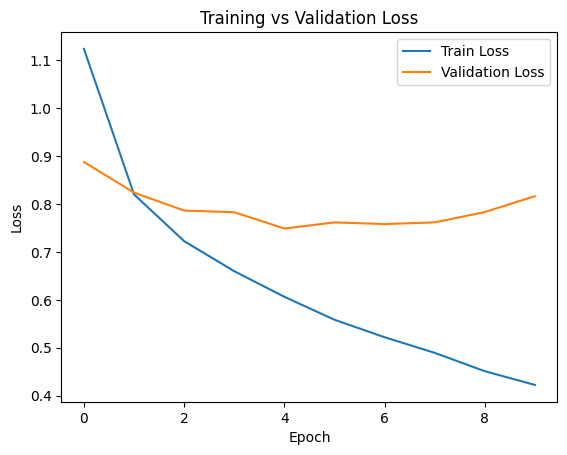

In [ ]:
plt.figure()
plt.plot(train_losses_tower, label="Train Loss")
plt.plot(val_losses_tower, label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.show()

# Code auto completed by Co-Pilot

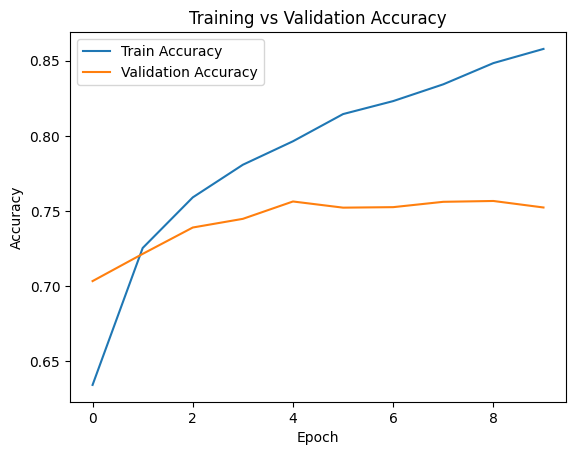

In [ ]:
plt.figure()
plt.plot(train_accuracies_tower, label="Train Accuracy")
plt.plot(val_accuracies_tower, label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.show()

# Code auto completed by Co-Pilot

## Inferene on Test Data

In [ ]:
tower_model.eval()
test_correct_tower = 0
test_total_tower = 0

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)

        outputs = tower_model(X_batch)
        preds = torch.argmax(outputs, dim=1)

        test_correct_tower += (preds == y_batch).sum().item()
        test_total_tower += y_batch.size(0)

test_accuracy_tower = test_correct_tower / test_total_tower
print("Test Accuracy:", test_accuracy_tower)

# Code auto completed by Co-Pilot

Test Accuracy: 0.7516666666666667


# Champion Model

## Feature Engineering

In [ ]:
import torch

def extract_features(x_flat):
    """
    Feature extractor for 15-class Quick Draw dataset:
    ['apple', 'baseballbat', 'basketball', 'clock', 'compass', 'cookie',
     'donut', 'ladder', 'mountain', 'pizza', 'rabbit', 'soccerball',
     'spider', 't-shirt', 'wheel']

    Input:  (N, 784) tensor, values in [0,1] or [0,255]
    Output: (N, 921) tensor
    """
    N = x_flat.shape[0]
    x = x_flat / 255.0 if x_flat.max() > 1.0 else x_flat
    img = x.reshape(N, 28, 28)
    features = []

    # ── 1. Raw pixels (784) ───────────────────────────────────────────────
    features.append(x)

    # ── 2. Row & column brightness profiles (56) ──────────────────────────
    # Captures overall shape: triangle (mountain), rectangle (ladder), circle (wheel)
    row_profile = img.mean(dim=2)   # (N, 28) — brightness top to bottom
    col_profile = img.mean(dim=1)   # (N, 28) — brightness left to right
    features += [row_profile, col_profile]

    # ── 3. Quadrant brightness (4) ────────────────────────────────────────
    # t-shirt: heavy top, mountain: heavy bottom, baseballbat: heavy one side
    tl = img[:, :14, :14].mean(dim=(1,2))
    tr = img[:, :14, 14:].mean(dim=(1,2))
    bl = img[:, 14:, :14].mean(dim=(1,2))
    br = img[:, 14:, 14:].mean(dim=(1,2))
    features.append(torch.stack([tl, tr, bl, br], dim=1))

    # ── 4. Top-heavy vs bottom-heavy, left vs right (2) ───────────────────
    # mountain: bottom-heavy, apple: slight top bump (stem), ladder: balanced
    top_heavy  = img[:, :14, :].mean(dim=(1,2)) - img[:, 14:, :].mean(dim=(1,2))
    left_heavy = img[:, :, :14].mean(dim=(1,2)) - img[:, :, 14:].mean(dim=(1,2))
    features.append(torch.stack([top_heavy, left_heavy], dim=1))

    # ── 5. Center vs border — detects hollow shapes (3) ───────────────────
    # donut, wheel, clock, basketball, soccerball all have hollow centers
    center = img[:, 10:18, 10:18].mean(dim=(1,2))
    border = (img[:, :3, :].mean(dim=(1,2)) +
              img[:, 25:, :].mean(dim=(1,2)) +
              img[:, :, :3].mean(dim=(1,2)) +
              img[:, :, 25:].mean(dim=(1,2))) / 4
    hollow_score = center / (border + 1e-6)   # low = hollow (donut, wheel)
    features.append(torch.stack([center, border, hollow_score], dim=1))

    # ── 6. Three-ring intensity (3) ───────────────────────────────────────
    # Helps separate: wheel/clock (ring of ink) vs pizza/cookie (filled circle)
    inner  = img[:,  9:19,  9:19].mean(dim=(1,2))   # inner 10×10
    middle = img[:,  5:23,  5:23].mean(dim=(1,2))   # middle 18×18
    outer  = img[:,  1:27,  1:27].mean(dim=(1,2))   # outer 26×26
    features.append(torch.stack([inner, middle, outer], dim=1))

    # ── 7. Horizontal & vertical edge strength (4) ────────────────────────
    # spider has many edges (legs), basketball/soccerball have curved edges
    h_edges = (img[:, 1:, :] - img[:, :-1, :]).abs()   # (N, 27, 28)
    v_edges = (img[:, :, 1:] - img[:, :, :-1]).abs()   # (N, 28, 27)
    features.append(torch.stack([
        h_edges.mean(dim=(1,2)),
        h_edges.max(dim=2).values.max(dim=1).values,
        v_edges.mean(dim=(1,2)),
        v_edges.max(dim=2).values.max(dim=1).values,
    ], dim=1))

    # ── 8. Edge profiles per row & col (54) ───────────────────────────────
    # ladder: uniform edge cols, mountain: edges only at bottom/sides
    h_edge_row = h_edges.mean(dim=2)   # (N, 27)
    v_edge_col = v_edges.mean(dim=1)   # (N, 27)
    features += [h_edge_row, v_edge_col]

    # ── 9. Left-right & top-bottom symmetry (2) ───────────────────────────
    # wheel, clock, donut, apple: symmetric | baseballbat, spider: asymmetric
    lr_sym = 1 - (img[:, :, :14] - img[:, :, 14:].flip(2)).abs().mean(dim=(1,2))
    tb_sym = 1 - (img[:, :14, :] - img[:, 14:, :].flip(1)).abs().mean(dim=(1,2))
    features.append(torch.stack([lr_sym, tb_sym], dim=1))

    # ── 10. Ink amount, centroid, bounding box (6) ────────────────────────
    # baseballbat: off-center, tall narrow bbox | t-shirt: wide bbox
    binary  = (img > 0.3).float()
    total   = binary.sum(dim=(1,2)) + 1e-6
    ink_frac = total / 784

    row_idx = torch.arange(28, device=x.device, dtype=x.dtype)
    col_idx = torch.arange(28, device=x.device, dtype=x.dtype)
    cy = (binary * row_idx[None, :, None]).sum(dim=(1,2)) / total
    cx = (binary * col_idx[None, None, :]).sum(dim=(1,2)) / total

    height = binary.any(dim=2).float().sum(dim=1) / 28   # normalized height
    width  = binary.any(dim=1).float().sum(dim=1) / 28   # normalized width
    aspect = height / (width + 1e-6)   # >1 = tall (ladder, baseballbat), <1 = wide (mountain)

    features.append(torch.stack([ink_frac, cx/28, cy/28, height, width, aspect], dim=1))

    # ── 11. Diagonal brightness (2) ───────────────────────────────────────
    # compass needle, baseballbat: strong diagonal signal
    diag_main = torch.diagonal(img, dim1=1, dim2=2).mean(dim=1, keepdim=True)
    diag_anti = torch.diagonal(img.flip(2), dim1=1, dim2=2).mean(dim=1, keepdim=True)
    features += [diag_main, diag_anti]

    # ── 12. How spread out is the ink? (2) ────────────────────────────────
    # spider: ink spread all over | apple: ink concentrated in blob
    row_std = img.mean(dim=2).std(dim=1, keepdim=True)   # variation across rows
    col_std = img.mean(dim=1).std(dim=1, keepdim=True)   # variation across cols
    features += [row_std, col_std]

    return torch.cat(features, dim=1)


In [ ]:
X_train_feat = extract_features(X_train_tensor)
X_val_feat   = extract_features(X_val_tensor)
X_test_feat  = extract_features(X_test_tensor)

train_dataset = TensorDataset(X_train_feat, y_train_tensor)
val_dataset   = TensorDataset(X_val_feat,   y_val_tensor)
test_dataset  = TensorDataset(X_test_feat,  y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=batch_size)
test_loader  = DataLoader(test_dataset,  batch_size=batch_size)

# Code auto completed by Co-Pilot


## Data Augmentation (Not Used)

In [ ]:
class DataAugmentation(torch.utils.data.Dataset):
    def __init__(self, data, labels, augment=False):
        self.data = data        # shape (N, 784)
        self.labels = labels
        self.augment = augment
        
        self.transform = transforms.Compose([
            transforms.RandomRotation(15),
            transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),  # shift
            transforms.RandomHorizontalFlip(),                          # mirror
        ])

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        x = self.data[idx].reshape(28, 28)          # un-flatten to 2D
        x = torch.tensor(x, dtype=torch.float32)
        x = x.unsqueeze(0)                           # (1, 28, 28) for transforms

        if self.augment:
            # transforms expect PIL or tensor
            x = self.transform(x)

        x = x.view(-1)                               # re-flatten to (784,)
        return x, self.labels[idx]

## Create Timestamp Folder for Each Run

In [296]:
# Create logs directory
BASE_LOG_DIR = "logs"
os.makedirs(BASE_LOG_DIR, exist_ok=True)

timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
RUN_DIR = os.path.join(BASE_LOG_DIR, timestamp)

os.makedirs(RUN_DIR, exist_ok=True)
os.makedirs(f"{RUN_DIR}/models", exist_ok=True)
os.makedirs(f"{RUN_DIR}/plots", exist_ok=True)

print("Experiment folder:", RUN_DIR)

Experiment folder: logs\20260302_221730


In [315]:
class ChampionModel(nn.Module):
    def __init__(self, input_size=846, num_classes=15):
        super(ChampionModel, self).__init__()

        # Stem
        self.fc1 = nn.Linear(input_size, 256)
        self.bn1 = nn.BatchNorm1d(256)
        self.drop1 = nn.Dropout(0.4)

        # Down projection
        self.down = nn.Linear(256, 128)

        # Residual Block 1
        self.rb1_fc1 = nn.Linear(128, 128)
        self.rb1_bn1 = nn.BatchNorm1d(128)
        self.rb1_drop = nn.Dropout(0.2)
        self.rb1_fc2 = nn.Linear(128, 128)
        self.rb1_bn2 = nn.BatchNorm1d(128)

        # Residual Block 2
        self.rb2_fc1 = nn.Linear(128, 128)
        self.rb2_bn1 = nn.BatchNorm1d(128)
        self.rb2_drop = nn.Dropout(0.2)
        self.rb2_fc2 = nn.Linear(128, 128)
        self.rb2_bn2 = nn.BatchNorm1d(128)

        # Head
        self.fc2 = nn.Linear(128, 64)
        self.bn2 = nn.BatchNorm1d(64)
        self.drop2 = nn.Dropout(0.1)
        self.fc3 = nn.Linear(64, num_classes)

        # Weight initialization
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight, nonlinearity='relu')
                nn.init.zeros_(m.bias)

    def forward(self, x):
        # 1. Flatten
        x = x.view(x.size(0), -1)

        # 2. Stem
        x = self.fc1(x)
        x = self.bn1(x)
        x = F.gelu(x)
        x = self.drop1(x)

        # 3. Down projection
        x = self.down(x)
        x = F.gelu(x)

        # 4. Residual Block 1
        residual = x
        x = self.rb1_fc1(x)
        x = self.rb1_bn1(x)
        x = F.gelu(x)
        x = self.rb1_drop(x)
        x = self.rb1_fc2(x)
        x = self.rb1_bn2(x)
        x = F.gelu(x + residual)

        # 5. Residual Block 2
        residual = x
        x = self.rb2_fc1(x)
        x = self.rb2_bn1(x)
        x = F.gelu(x)
        x = self.rb2_drop(x)
        x = self.rb2_fc2(x)
        x = self.rb2_bn2(x)
        x = F.gelu(x + residual)


        # 7. Head
        x = self.fc2(x)
        x = self.bn2(x)
        x = F.gelu(x)
        x = self.drop2(x)
        x = self.fc3(x)

        return x

In [298]:
config = {
    "learning_rate": 0.001,
    "epochs": 40,
    "optimizer": "AdamW",
    "weight_decay": 0.0001,
    "label_smoothing": 0.1,
}

with open(f"{RUN_DIR}/config.json", "w") as f:
    json.dump(config, f, indent=4)

In [ ]:
model = ChampionModel(input_size=train_dataset.tensors[0].shape[1]).to(device)

criterion = nn.CrossEntropyLoss(label_smoothing=config['label_smoothing'])

optimizer = optim.AdamW(
    model.parameters(),
    lr=config["learning_rate"],
    weight_decay=config["weight_decay"]
)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='max',          # monitor val accuracy
    factor=0.5,          # halve the LR on plateau
    patience=3,          # wait 3 epochs before reducing
    min_lr=1e-6,
)

In [300]:
train_losses, val_losses = [], []
train_accs, val_accs = [], []

In [301]:
for epoch in range(config["epochs"]):

    # ---- TRAIN ----
    model.train()
    train_loss = 0
    correct = 0
    total = 0

    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)

        optimizer.zero_grad()

        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 2.0)
        optimizer.step()

        train_loss += loss.item()

        preds = torch.argmax(outputs, dim=1)
        correct += (preds == y_batch).sum().item()
        total += y_batch.size(0)

    train_loss /= len(train_loader)
    train_acc = correct / total

    # ---- VALIDATION ----
    model.eval()
    val_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)

            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)

            val_loss += loss.item()

            preds = torch.argmax(outputs, dim=1)
            correct += (preds == y_batch).sum().item()
            total += y_batch.size(0)

    val_loss /= len(val_loader)
    val_acc = correct / total

    # ---- SCHEDULER STEP (plateau: step after val) ----
    scheduler.step(val_acc)

    # Store metrics
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)

    # ✅ Save model EACH epoch
    torch.save(
        model.state_dict(),
        f"{RUN_DIR}/models/model_epoch_{epoch+1}.pt"
    )

    current_lr = optimizer.param_groups[0]['lr']
    print(f"Epoch {epoch+1}: Train Acc={train_acc:.4f}, Val Acc={val_acc:.4f} | LR={current_lr:.2e}")

Epoch 1: Train Acc=0.5699, Val Acc=0.7009 | LR=1.00e-03
Epoch 2: Train Acc=0.6889, Val Acc=0.7378 | LR=1.00e-03
Epoch 3: Train Acc=0.7213, Val Acc=0.7574 | LR=1.00e-03
Epoch 4: Train Acc=0.7426, Val Acc=0.7642 | LR=1.00e-03
Epoch 5: Train Acc=0.7606, Val Acc=0.7730 | LR=1.00e-03
Epoch 6: Train Acc=0.7754, Val Acc=0.7777 | LR=1.00e-03
Epoch 7: Train Acc=0.7848, Val Acc=0.7806 | LR=1.00e-03
Epoch 8: Train Acc=0.7953, Val Acc=0.7879 | LR=1.00e-03
Epoch 9: Train Acc=0.8011, Val Acc=0.7894 | LR=1.00e-03
Epoch 10: Train Acc=0.8084, Val Acc=0.7926 | LR=1.00e-03
Epoch 11: Train Acc=0.8165, Val Acc=0.7949 | LR=1.00e-03
Epoch 12: Train Acc=0.8233, Val Acc=0.7966 | LR=1.00e-03
Epoch 13: Train Acc=0.8276, Val Acc=0.7989 | LR=1.00e-03
Epoch 14: Train Acc=0.8327, Val Acc=0.7991 | LR=1.00e-03
Epoch 15: Train Acc=0.8382, Val Acc=0.7986 | LR=1.00e-03
Epoch 16: Train Acc=0.8410, Val Acc=0.8014 | LR=1.00e-03
Epoch 17: Train Acc=0.8441, Val Acc=0.8010 | LR=1.00e-03
Epoch 18: Train Acc=0.8494, Val Acc=0.79

In [302]:
torch.save(model.state_dict(), f"{RUN_DIR}/models/final_model.pt")

In [303]:
metrics = {
    "train_loss": train_losses,
    "val_loss": val_losses,
    "train_accuracy": train_accs,
    "val_accuracy": val_accs
}

with open(f"{RUN_DIR}/metrics.json", "w") as f:
    json.dump(metrics, f, indent=4)

In [304]:
plt.figure()
plt.plot(train_losses, label="Train")
plt.plot(val_losses, label="Validation")
plt.title("Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.savefig(f"{RUN_DIR}/plots/loss_curve.png")
plt.close()

In [305]:
plt.figure()
plt.plot(train_accs, label="Train")
plt.plot(val_accs, label="Validation")
plt.title("Accuracy Curve")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.savefig(f"{RUN_DIR}/plots/accuracy_curve.png")
plt.close()

In [306]:
def extract_model_structure(model):
    layers_info = []

    for name, module in model.named_modules():
        if name == "":
            continue

        layer_details = {
            "layer_name": name,
            "layer_type": module.__class__.__name__
        }

        # Save key parameters if Linear layer
        if isinstance(module, nn.Linear):
            layer_details["in_features"] = module.in_features
            layer_details["out_features"] = module.out_features

        layers_info.append(layer_details)

    return layers_info

In [307]:
model_structure = extract_model_structure(model)

with open(f"{RUN_DIR}/model_structure.json", "w") as f:
    json.dump(model_structure, f, indent=4)

In [308]:
with open(f"{RUN_DIR}/model_summary.txt", "w") as f:
    f.write(str(model))

In [309]:
activation_types = (
    nn.ReLU,
    nn.GELU,
    nn.Sigmoid,
    nn.Tanh,
    nn.LeakyReLU,
    nn.ELU
)

activations_used = []

for module in model.modules():
    if isinstance(module, activation_types):
        activations_used.append(module.__class__.__name__)

activations_used = list(set(activations_used))

with open(f"{RUN_DIR}/activations.json", "w") as f:
    json.dump({"activations": activations_used}, f, indent=4)

In [310]:
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

param_info = {
    "total_parameters": total_params,
    "trainable_parameters": trainable_params
}

with open(f"{RUN_DIR}/parameter_info.json", "w") as f:
    json.dump(param_info, f, indent=4)

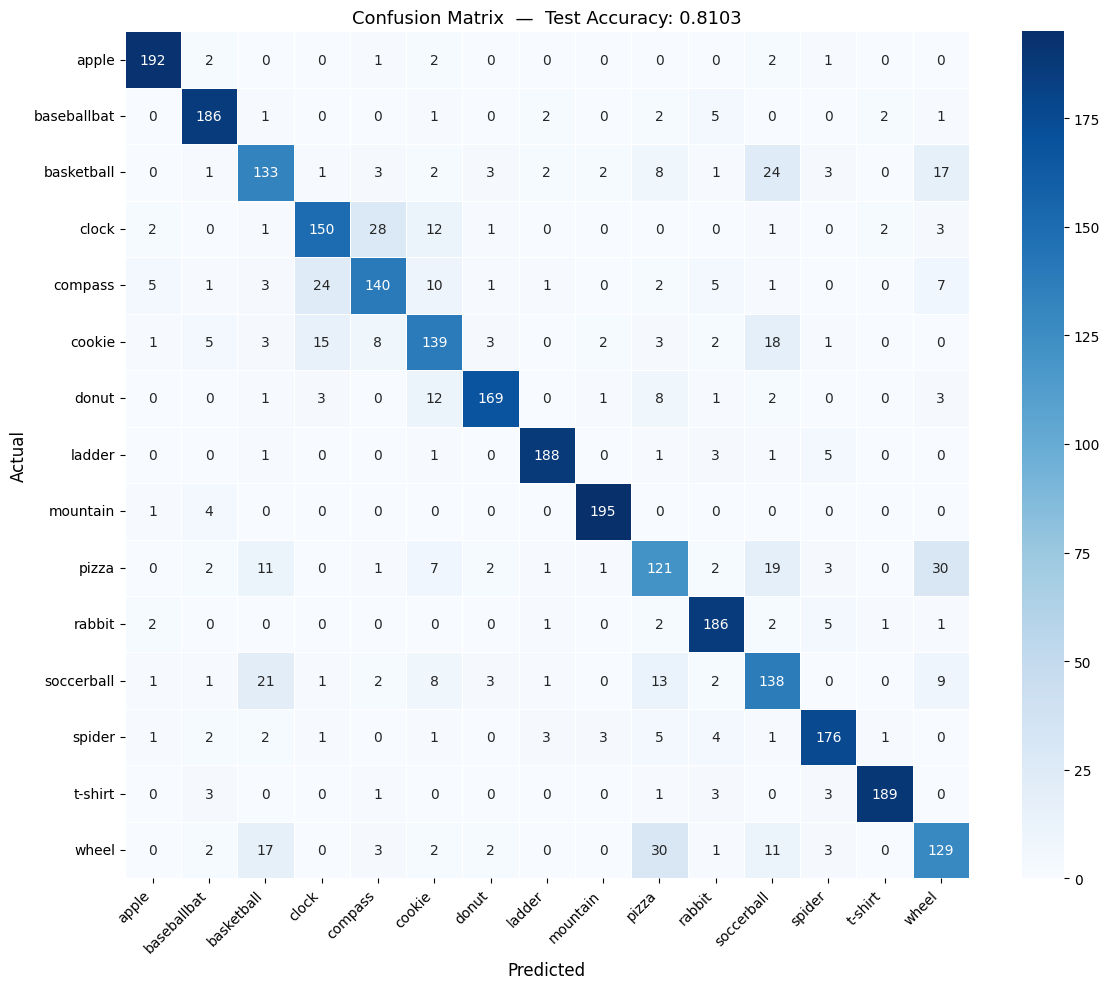

Saved → logs\20260302_221730/confusion_matrix.png
Test Accuracy: 0.8103
              precision    recall  f1-score   support

       apple       0.94      0.96      0.95       200
 baseballbat       0.89      0.93      0.91       200
  basketball       0.69      0.67      0.68       200
       clock       0.77      0.75      0.76       200
     compass       0.75      0.70      0.72       200
      cookie       0.71      0.69      0.70       200
       donut       0.92      0.84      0.88       200
      ladder       0.94      0.94      0.94       200
    mountain       0.96      0.97      0.97       200
       pizza       0.62      0.60      0.61       200
      rabbit       0.87      0.93      0.90       200
  soccerball       0.63      0.69      0.66       200
      spider       0.88      0.88      0.88       200
     t-shirt       0.97      0.94      0.96       200
       wheel       0.65      0.65      0.65       200

    accuracy                           0.81      3000
   macro

In [ ]:
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        outputs = model(X_batch)
        preds = torch.argmax(outputs, dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(y_batch.cpu().numpy())

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)
test_acc   = (all_preds == all_labels).mean()

# ── Confusion Matrix ──────────────────────────────────────────────────────────
CLASS_NAMES = ['apple', 'baseballbat', 'basketball', 'clock', 'compass',
               'cookie', 'donut', 'ladder', 'mountain', 'pizza',
               'rabbit', 'soccerball', 'spider', 't-shirt', 'wheel']

cm = confusion_matrix(all_labels, all_preds)

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
            linewidths=0.5, ax=ax)
ax.set_xlabel('Predicted', fontsize=12)
ax.set_ylabel('Actual', fontsize=12)
ax.set_title(f'Confusion Matrix  —  Test Accuracy: {test_acc:.4f}', fontsize=13)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig(f"{RUN_DIR}/confusion_matrix.png", dpi=150)
plt.show()
print(f"Saved → {RUN_DIR}/confusion_matrix.png")

# ── Text results ──────────────────────────────────────────────────────────────
with open(f"{RUN_DIR}/test_results.txt", "w") as f:
    f.write(f"Test Accuracy: {test_acc:.4f}\n\n")
    f.write(classification_report(all_labels, all_preds, target_names=CLASS_NAMES))

print(f"Test Accuracy: {test_acc:.4f}")
print(classification_report(all_labels, all_preds, target_names=CLASS_NAMES))

# Code written using  Co-Pilot

# Inference on Test Set

In [322]:

# ======================================================
# CONFIG
# ======================================================

MODEL_PATH = "logs/20260302_211223/models/final_model.pt"
DATA_DIR = "processed_data/"
TEST_FILE = "quickdraw_test.npz"
OUTPUT_FILE = "predictions_3.txt"

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")


# ======================================================
# LOAD MODEL
# ======================================================

print("Loading model...")

model = ChampionModel(input_size=922)
model.load_state_dict(torch.load(MODEL_PATH, map_location=DEVICE))
model.to(DEVICE)
model.eval()

print("Model loaded.")


# ======================================================
# LOAD DATA
# ======================================================

print("Loading test data...")

test_data = np.load(os.path.join(DATA_DIR, TEST_FILE))
X_test_final = test_data["test_images"]

# ======================================================
# PREPROCESS
# ======================================================

X_test_final = X_test_final /255.0
X_tensor = torch.from_numpy(X_test_final).float().to(DEVICE)
X_tensor = extract_features(X_tensor)

# ======================================================
# INFERENCE
# ======================================================

print("Running inference...")

with torch.no_grad():
    outputs = model(X_tensor)
    predictions = torch.argmax(outputs, dim=1).cpu().numpy()


# ======================================================
# SAVE COMMA-SEPARATED OUTPUT
# ======================================================

print("Saving predictions...")

with open(OUTPUT_FILE, "w") as f:
    f.write(",".join(map(str, predictions)))

print(f"Predictions saved → {OUTPUT_FILE}")
print("Done.")

Loading model...
Model loaded.
Loading test data...
Running inference...
Saving predictions...
Predictions saved → predictions_3.txt
Done.
